# Batter Fantasy Point Predictions for 2026
Loads the best saved MVT batter model from `results/batter_model/` and generates
2026 feature predictions using each batter's stats through the 2025 season.
Fantasy points are computed by applying `score_map` to the predicted counting stats.

In [1]:
RESULTS_DIR = './results/batter_model/'
DATA_PATH   = './data/batting_stats.csv'
PRED_SEASON = 2025   # most-recent season used as the last lookback window
PRED_YEAR   = 2026   # the year we are forecasting
DEVICE      = 'mps'  # 'mps' for Apple Silicon, 'cpu' for fallback
MIN_QUAL_PA = 50     # minimum PA in PRED_SEASON to include a batter
OUTPUT_CSV  = f'./results/batter_model/predictions_{PRED_YEAR}.csv'

In [2]:
import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.mvt_batter_model import MVTBatterModel, MVTBatterPredictionDataset

device = torch.device(DEVICE if DEVICE == 'mps' and torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## 1. Load metadata

In [3]:
with open(os.path.join(RESULTS_DIR, 'metadata.json')) as f:
    metadata = json.load(f)

hyperparams   = metadata['hyperparameters']
features      = metadata['features']
score_map     = metadata['score_map']
feature_stats = metadata['feature_stats']   # {name: [mean, std]}
saved_metrics = metadata['metrics']
nlookbacks    = hyperparams['nlookbacks']

print(f'Features      : {len(features)}')
print(f'nlookbacks    : {nlookbacks}')
print(f'Overall MSE   : {saved_metrics["overall_mse"]:.4f}')
print(f'Overall MAE   : {saved_metrics["overall_mae"]:.4f}')
print(f'Overall R²    : {saved_metrics["overall_r2"]:.4f}')
print(f'Score map keys: {list(score_map.keys())}')

Features      : 34
nlookbacks    : 8
Overall MSE   : 0.6055
Overall MAE   : 0.5818
Overall R²    : 0.4290
Score map keys: ['R', '1B', '2B', '3B', 'HR', 'RBI', 'BB', 'SO', 'HBP', 'SB', 'CS', 'GDP']


## 2. Load batting data

In [4]:
need_download = True
if os.path.exists(DATA_PATH):
    data = pd.read_csv(DATA_PATH)
    if 'PA' in data.columns:
        need_download = False
        print(f'Loaded {DATA_PATH}: {len(data)} rows')

if need_download:
    print('Downloading batting stats via pybaseball…')
    from pybaseball import batting_stats
    data = batting_stats(start_season=2015, end_season=2025, qual=10)
    data.to_csv(DATA_PATH, index=False)
    print(f'Saved {len(data)} rows to {DATA_PATH}')

data = data[data['Season'] <= PRED_SEASON].copy()
print(f'Seasons available: {sorted(data["Season"].unique())}')
print(f'Batters in {PRED_SEASON}: {len(data[data["Season"] == PRED_SEASON])}')

Loaded ./data/batting_stats.csv: 5873 rows
Seasons available: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Batters in 2025: 537


## 3. Rebuild model & load weights

In [5]:
model = MVTBatterModel(
    input_dim       = len(features),
    num_features    = len(features),
    d_model         = hyperparams['d_model'],
    nhead           = hyperparams['nhead'],
    num_layers      = hyperparams['num_layers'],
    dim_feedforward = hyperparams['dim_feedforward'],
    dropout         = hyperparams['dropout'],
    nlookbacks      = nlookbacks,
)

weights_path = os.path.join(RESULTS_DIR, 'best_model.pt')
model.load_state_dict(torch.load(weights_path, map_location='cpu'))
model = model.to(device)
model.eval()
print(f'Model loaded from {weights_path}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Model loaded from ./results/batter_model/best_model.pt
Parameters: 84,258


## 4. Load scaler

In [6]:
with open(os.path.join(RESULTS_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
print(f'Scaler loaded: {type(scaler).__name__}')

Scaler loaded: StandardScaler


## 5. Build prediction sequences

In [7]:
pred_ds = MVTBatterPredictionDataset(
    data        = data,
    pred_season = PRED_SEASON,
    features    = features,
    nlookbacks  = nlookbacks,
)
pred_sequences = pred_ds.pred_sequences  # (N, nlookbacks, num_features)
pred_meta      = pred_ds.pred_metadata   # DataFrame indexed by player_id

print(f'Prediction sequences: {pred_sequences.shape}')
print(f'Players to predict  : {len(pred_meta)}')

Prediction sequences: torch.Size([537, 8, 34])
Players to predict  : 537


## 6. Scale & run inference

In [8]:
X_np = pred_sequences.numpy()
N, seq_len, num_feat = X_np.shape

X_scaled = scaler.transform(X_np.reshape(-1, num_feat)).reshape(N, seq_len, num_feat)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

all_preds = []
batch_size = 64

with torch.no_grad():
    for start in range(0, N, batch_size):
        batch = X_tensor[start:start + batch_size]
        preds = model(batch)   # (B, num_features)
        all_preds.extend(preds.cpu().numpy())

all_preds = np.array(all_preds)  # (N, num_features)

# Denormalise using per-feature stats from training
preds_denorm = np.zeros_like(all_preds)
for i, fname in enumerate(features):
    mean, std = feature_stats[fname]
    preds_denorm[:, i] = all_preds[:, i] * std + mean

print(f'Predictions generated: {len(preds_denorm)}')

Predictions generated: 537


## 7. Assemble results & compute fantasy points

In [9]:
results = pred_meta.copy().reset_index()
results.rename(columns={'player_id': 'IDfg'}, inplace=True)

# Attach predicted feature columns
for i, fname in enumerate(features):
    results[f'predicted_{fname}_{PRED_YEAR}'] = preds_denorm[:, i]

# Fantasy points via score_map
results[f'predicted_points_{PRED_YEAR}'] = 0.0
for stat, weight in score_map.items():
    col = f'predicted_{stat}_{PRED_YEAR}'
    if col in results.columns:
        results[f'predicted_points_{PRED_YEAR}'] += results[col] * weight

# Join player info from PRED_SEASON
info_cols = ['IDfg', 'Name', 'Team', 'Age', 'PA']
available_info = [c for c in info_cols if c in data.columns]
info_season = (
    data[data['Season'] == PRED_SEASON][available_info]
    .drop_duplicates('IDfg')
)
if 'PA' in info_season.columns:
    info_season = info_season[info_season['PA'] >= MIN_QUAL_PA]

results = results.merge(info_season, on='IDfg', how='left')
results = results.sort_values(f'predicted_points_{PRED_YEAR}', ascending=False).reset_index(drop=True)
results.insert(0, 'Rank', results.index + 1)

# Display top 30
display_cols = ['Rank', 'Name', 'Team', 'Age', 'PA', f'predicted_points_{PRED_YEAR}']
display_cols += [f'predicted_{s}_{PRED_YEAR}' for s in score_map]
display_cols = [c for c in display_cols if c in results.columns]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(results[display_cols].head(30).to_string(index=False))

 Rank                  Name  Team  Age  PA  predicted_points_2026  predicted_R_2026  predicted_1B_2026  predicted_2B_2026  predicted_3B_2026  predicted_HR_2026  predicted_RBI_2026  predicted_BB_2026  predicted_SO_2026  predicted_HBP_2026  predicted_SB_2026  predicted_CS_2026  predicted_GDP_2026
    1           Aaron Judge   NYY   33 679             433.729667        111.266533          93.383820          33.397373           1.609945          41.469624          112.532387          97.069679         169.405457            7.308290          10.603651           2.437003           15.316527
    2         Shohei Ohtani   LAD   30 727             419.893585        112.312271          89.514236          34.129738           3.831348          37.767696          104.742615          84.056755         170.082703            6.173457          20.291420           4.908841           10.117403
    3             Juan Soto   NYM   26 715             416.840459        108.981834          94.826492          

## 8. Visualisations

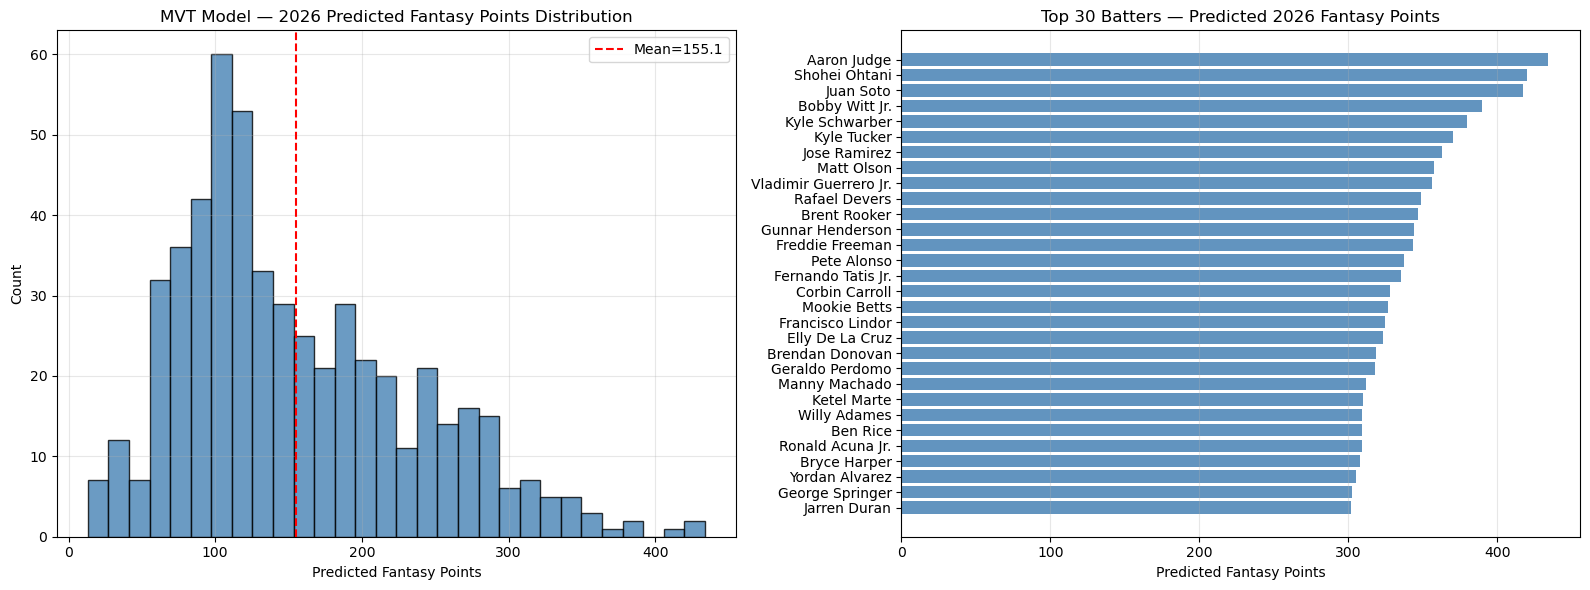

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fantasy points distribution
pts = results[f'predicted_points_{PRED_YEAR}']
axes[0].hist(pts, bins=30, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].axvline(pts.mean(), color='red', linestyle='--', label=f'Mean={pts.mean():.1f}')
axes[0].set_xlabel('Predicted Fantasy Points')
axes[0].set_ylabel('Count')
axes[0].set_title(f'MVT Model — {PRED_YEAR} Predicted Fantasy Points Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top-30 bar chart
top30 = results.head(30)
label_col = 'Name' if 'Name' in top30.columns else 'IDfg'
labels = top30[label_col].astype(str).tolist()[::-1]
values = top30[f'predicted_points_{PRED_YEAR}'].tolist()[::-1]
axes[1].barh(labels, values, color='steelblue', alpha=0.85)
axes[1].set_xlabel('Predicted Fantasy Points')
axes[1].set_title(f'Top 30 Batters — Predicted {PRED_YEAR} Fantasy Points')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

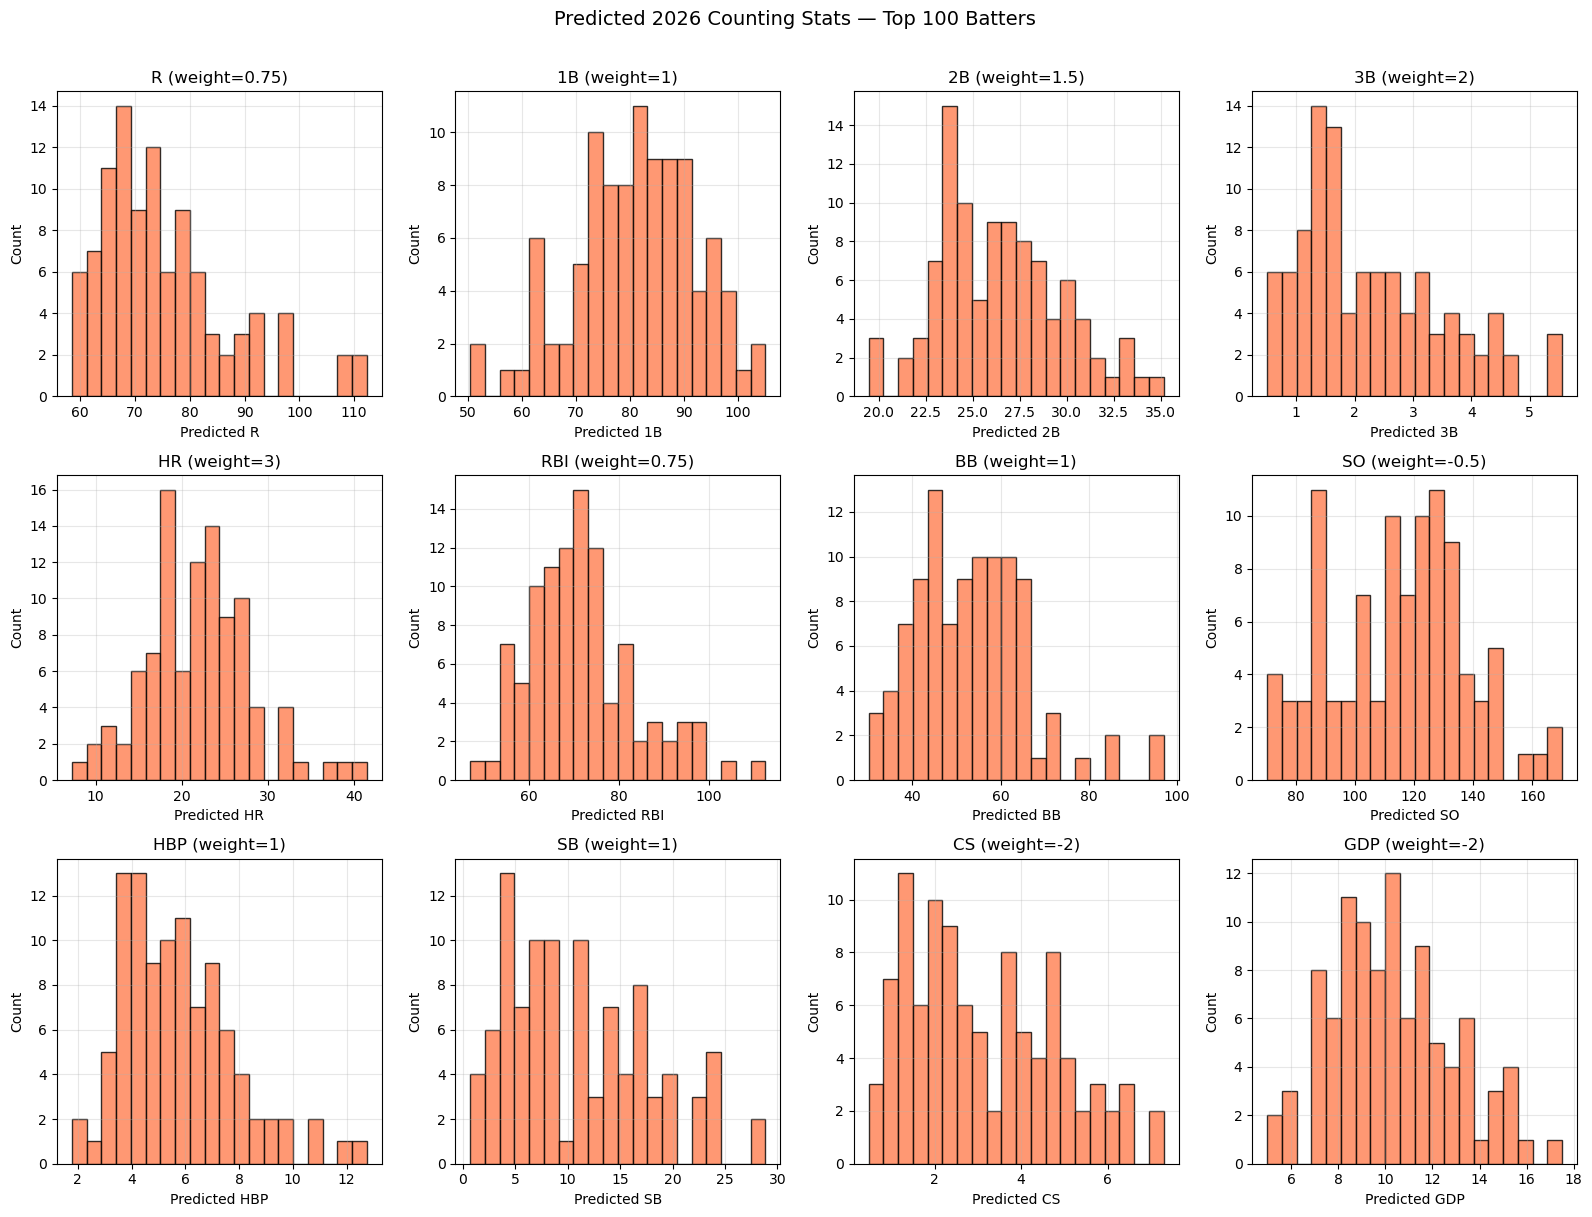

In [11]:
# Predicted counting stat distributions for top-100 batters
top100 = results.head(100)
stat_cols = [s for s in score_map if f'predicted_{s}_{PRED_YEAR}' in top100.columns]
ncols = 4
nrows = (len(stat_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for idx, stat in enumerate(stat_cols):
    col = f'predicted_{stat}_{PRED_YEAR}'
    axes[idx].hist(top100[col], bins=20, edgecolor='black', color='coral', alpha=0.8)
    axes[idx].set_title(f'{stat} (weight={score_map[stat]})')
    axes[idx].set_xlabel(f'Predicted {stat}')
    axes[idx].set_ylabel('Count')
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(stat_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Predicted {PRED_YEAR} Counting Stats — Top 100 Batters', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Save predictions

In [12]:
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
results.to_csv(OUTPUT_CSV, index=False)
print(f'Saved {len(results)} predictions to {OUTPUT_CSV}')
results[display_cols].head(10)

Saved 537 predictions to ./results/batter_model/predictions_2026.csv


,Rank,Name,Team,Age,PA,predicted_points_2026,predicted_R_2026,predicted_1B_2026,predicted_2B_2026,predicted_3B_2026,predicted_HR_2026,predicted_RBI_2026,predicted_BB_2026,predicted_SO_2026,predicted_HBP_2026,predicted_SB_2026,predicted_CS_2026,predicted_GDP_2026
0,1,Aaron Judge,NYY,33,679,433.729667,111.266533,93.383820,33.397373,1.609945,41.469624,112.532387,97.069679,169.405457,7.308290,10.603651,2.437003,15.316527
1,2,Shohei Ohtani,LAD,30,727,419.893585,112.312271,89.514236,34.129738,3.831348,37.767696,104.742615,84.056755,170.082703,6.173457,20.291420,4.908841,10.117403
2,3,Juan Soto,NYM,26,715,416.840459,108.981834,94.826492,32.419125,2.345273,34.537636,99.283073,96.273178,146.661041,5.115473,14.532491,3.657940,13.195795
3,4,Bobby Witt Jr.,KCR,25,687,389.671009,107.681686,105.004196,35.172367,5.327502,28.130943,88.138687,59.724613,146.514038,7.824888,28.850523,7.301459,9.272470
4,5,Kyle Schwarber,PHI,32,724,379.297072,98.121475,73.689438,29.756172,1.711180,38.264923,98.891388,85.987648,163.325623,7.700996,8.374352,2.255832,10.445962
5,6,Kyle Tucker,CHC,28,597,370.088014,97.972336,94.005188,32.952866,3.470885,26.692253,87.482384,71.155769,131.417419,4.948942,17.280769,4.372389,9.194014
6,7,Jose Ramirez,CLE,32,673,363.005068,96.186630,99.706757,33.421383,4.388638,23.158531,82.328842,57.778519,113.603943,5.723540,23.271820,5.873125,8.599445
7,8,Matt Olson,ATL,31,724,357.563680,90.178215,88.443008,30.728033,1.068135,32.675491,95.928818,77.009804,142.212219,5.335516,3.302709,0.956231,14.671924
8,9,Vladimir Guerrero Jr.,TOR,26,680,356.025919,89.435242,102.320274,31.832401,1.289149,27.660965,92.781143,70.866493,120.439590,5.649442,5.422846,1.483750,17.508965
9,10,Rafael Devers,- - -,28,729,348.592637,90.138420,90.426498,30.476131,1.020425,31.809620,97.114502,71.982376,147.278259,5.662071,4.207397,1.314516,15.520572
